Import Libraries

In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
from evojax.util import get_params_format_fn

import time
import numpy as np
import pandas as pd
from scipy import io
import matplotlib.pyplot as plt

# choose GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
#jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

Problem: Navier-Stokes Equation

        u*u_x + v*u_y - 1/Re*(u_xx+u_yy) + p_x = 0
        v*v_x + v*v_y - 1/Re*(v_xx+v_yy) + p_y = 0
        u_x + v_y = 0

In [2]:
# parameter
Re = 400

In [3]:
sim = pd.read_csv('RE{}_BK_GROUND_TRUTH_801X41.csv'.format(Re),sep=',')
print("x: ", sim['x'].shape, ", y: " , sim['y'].shape,", u: ", sim['u'].shape, ", v: " , sim['v'].shape)

x:  (32841,) , y:  (32841,) , u:  (32841,) , v:  (32841,)


In [4]:
sim

,x,y,u,v,p
0,0.000,-0.5,0.0,0.0,-0.084536
1,0.025,-0.5,0.0,0.0,-0.084549
2,0.050,-0.5,0.0,0.0,-0.084588
3,0.075,-0.5,0.0,0.0,-0.084644
4,0.100,-0.5,0.0,0.0,-0.084707
...,...,...,...,...,...
32836,19.900,0.5,0.0,0.0,0.001369
32837,19.925,0.5,0.0,0.0,0.000997
32838,19.950,0.5,0.0,0.0,0.000626
32839,19.975,0.5,0.0,0.0,0.000255


In [5]:
sim_x = sim['x'].values.reshape(-1,1)
sim_y = sim['y'].values.reshape(-1,1)
sim_u = sim['u'].values.reshape(-1,1)
sim_v = sim['v'].values.reshape(-1,1)
sim_p = sim['p'].values.reshape(-1,1)


In [6]:

x_l, x_u, y_l, y_u = np.min(sim_x), np.max(sim_x), np.min(sim_y), np.max(sim_y)

ext = [x_l, x_u, y_l, y_u]
print (x_l, x_u, y_l, y_u)

data_X, data_Y = np.hstack([sim_x, sim_y]), np.hstack([sim_u, sim_v, sim_p])

dx = dy = sim_x[2]-sim_x[1]
print ('dx:',dx, 'dy:',dy)



# pressure ref
x_ref, y_ref = np.unique(sim_x), np.unique(sim_y)

x_ref, y_ref = np.take(x_ref, x_ref.size //2), np.take(y_ref, y_ref.size //2)
print (x_ref, y_ref)

# split into BC data
bc = (data_X[:,0] == x_l) |  (data_X[:,1] == y_l) | (data_X[:,1] == y_u)
data_X_BC, data_Y_BC = data_X[bc], data_Y[bc]
data_X = data_X[~bc]
data_Y = data_Y[~bc]
print (data_X.shape, data_Y.shape, data_X_BC.shape, data_Y_BC.shape)

0.0 20.0 -0.5 0.5
dx: [0.025] dy: [0.025]
10.0 0.0
(31200, 2) (31200, 3) (1641, 2) (1641, 3)


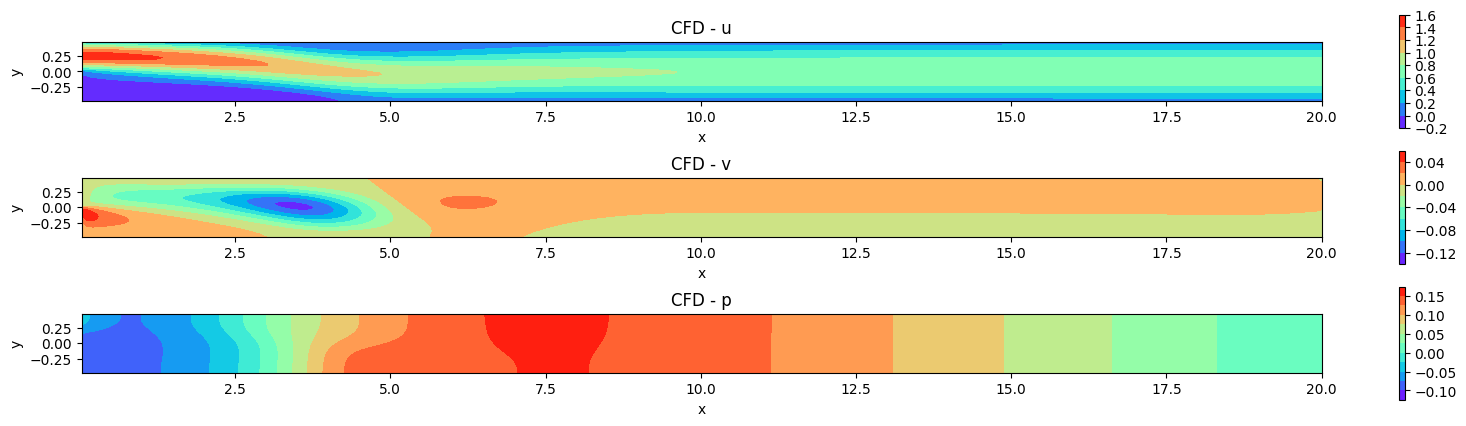

In [7]:
# plot
fig = plt.figure(figsize=(20, 5))
con_lv = 10
ax1 = fig.add_subplot(3,1,1,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,0], con_lv, origin='lower', cmap='rainbow', extent=ext);
# set the size of the color bar
plt.colorbar();
plt.xlabel('x'); plt.ylabel('y');plt.title('CFD - u');
ax1 = fig.add_subplot(3,1,2,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,1], con_lv, origin='lower', cmap='rainbow', extent=ext);
plt.colorbar();
plt.xlabel('x'); plt.ylabel('y'); plt.title('CFD - v'); 
ax1 = fig.add_subplot(3,1,3,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,2], con_lv, origin='lower', cmap='rainbow', extent=ext);
plt.colorbar();
plt.xlabel('x'); plt.ylabel('y'); plt.title('CFD - p');
# ax1 = fig.add_subplot(2,4,4,aspect='equal')
# plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,3], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN - T');
# enlarge the gap between plots
plt.subplots_adjust(wspace=0.0)
plt.show()

In [8]:
# convert to jnp
data_X, data_Y, data_X_BC, data_Y_BC = jnp.array(data_X), jnp.array(data_Y), jnp.array(data_X_BC), jnp.array(data_Y_BC)
print (data_X.shape, data_Y.shape, data_X_BC.shape, data_Y_BC.shape)

(31200, 2) (31200, 3) (1641, 2) (1641, 3)


2025-09-09 10:30:12.217834: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.6.77). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


DNN / PINN   

In [9]:
nn_acf = nn.silu

class PINN(nn.Module):
    """PINNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                    nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]     

    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
        def get_uvp(x, y):
            inputs = jnp.hstack([(x-x_l)/(x_u-x_l),(y-y_l)/(y_u-y_l)])
            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(2*jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)
            return (u, v, p)  
    
        u, v, p = get_uvp(x, y)

        
        def left_bc_fun(y):
            bc_left_bool = y >=0
            vw = jnp.where(bc_left_bool, 24*y*(0.5-y), 0.0)
            return u

        # axillary PDE outputs
        # discretization (1st order)
        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE = get_uvp(xE, y)
        uW, vW, pW = get_uvp(xW, y)
        uN, vN, pN = get_uvp(x, yN)
        uS, vS, pS = get_uvp(x, yS)
        ue, ve, pe = get_uvp(xe, y)
        uw, vw, pw = get_uvp(xw, y)
        un, vn, pn = get_uvp(x, yn)
        us, vs, ps = get_uvp(x, ys)

        # uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 0, 0
        uSbc, vSbc = 0, 0

        
        if(bi_count == 1):
         
            xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
            yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy           
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            # uE, vE = jnp.where(xB_E, uEbc, uE), jnp.where(xB_E, vEbc, vE)
            uW, vW = jnp.where(xB_W, left_bc_fun(y), uW), jnp.where(xB_W, vWbc, vW)
            uN, vN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN)
            uS, vS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS)

        if(bi_count == 1):
         
            xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
            yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy           
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            # ue, ve = jnp.where(xB_e, uEbc, ue), jnp.where(xB_e, vEbc, ve)
            uw, vw = jnp.where(xB_w, left_bc_fun(y), uw), jnp.where(xB_w, vWbc, vw)
            un, vn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn)
            us, vs = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs)

        ae = ue
        aw = -uw
        an = vn
        aas = -vs
        

        source_x = (pE - pW)/2
        source_y = (pN - pS)/2
        # obtain BC indices
        bc  = (x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)
        nbc = (~bc)
        
        div = (uE - uW + vN - vS)/2


        mom_x = ae*ue + aw*uw + an*un + aas*us + source_x - (uE + uW + uN + uS - 4*u)/(dx*Re) 
        mom_y = ae*ve + aw*vw + an*vn + aas*vs + source_y - (vE + vW + vN + vS - 4*v)/(dx*Re) 



        res_u = ( source_x - (uE + uW + uN + uS)/(dx*Re))/dx 
        res_v = ( source_y - (vE + vW + vN + vS)/(dx*Re))/dx
        
        residuals_continuity = div/dx
        residuals_momentum_1 = mom_x/dx
        residuals_momentum_2 = mom_y/dy 

        
        outputs = jnp.hstack([u, v, p, residuals_continuity, residuals_momentum_1, residuals_momentum_2, bc, nbc,res_u,res_v])
        return outputs        
    
class DNN(nn.Module):
    """DNNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]    

    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
        def get_uvp(x, y):
            inputs = jnp.hstack([(x-x_l)/(x_u-x_l),(y-y_l)/(y_u-y_l) ])
            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(2*jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)
            return (u, v, p)  
            
        u, v, p = get_uvp(x, y)

        def left_bc_fun(y):
            bc_left_bool = y >=0
            vw = jnp.where(bc_left_bool, 24*y*(0.5-y), 0.0)
            return u

       # axillary PDE outputs
        # discretization (1st order)
        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE = get_uvp(xE, y)
        uW, vW, pW = get_uvp(xW, y)
        uN, vN, pN = get_uvp(x, yN)
        uS, vS, pS = get_uvp(x, yS)
        ue, ve, pe = get_uvp(xe, y)
        uw, vw, pw = get_uvp(xw, y)
        un, vn, pn = get_uvp(x, yn)
        us, vs, ps = get_uvp(x, ys)

        # uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 0, 0
        uSbc, vSbc = 0, 0


        if(bi_count == 1):
         
            xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
            yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy           
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            # uE, vE = jnp.where(xB_E, uEbc, uE), jnp.where(xB_E, vEbc, vE)
            uW, vW = jnp.where(xB_W, left_bc_fun(y), uW), jnp.where(xB_W, vWbc, vW)
            uN, vN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN)
            uS, vS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS)

        if(bi_count == 1):
         
            xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
            yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy           
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            # ue, ve = jnp.where(xB_e, uEbc, ue), jnp.where(xB_e, vEbc, ve)
            uw, vw = jnp.where(xB_w, left_bc_fun(y), uw), jnp.where(xB_w, vWbc, vw)
            un, vn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn)
            us, vs = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs)

        ae = ue
        aw = -uw
        an = vn
        aas = -vs
        
        source_x = (pE - pW)/2
        source_y = (pN - pS)/2
        # obtain BC indices
        bc  = (x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)
        
        div = (uE - uW + vN - vS)/2

        mom_x = ae*ue + aw*uw + an*un + aas*us + source_x - (uE + uW + uN + uS - 4*u)/(dx*Re) 
        mom_y = ae*ve + aw*vw + an*vn + aas*vs + source_y - (vE + vW + vN + vS - 4*v)/(dx*Re) 
        
        residuals_momentum_1 = mom_x/dx
        residuals_momentum_2 = mom_y/dy 

        res_u = ( source_x - (uE + uW + uN + uS)/(dx*Re))/dx 
        res_v = ( source_y - (vE + vW + vN + vS)/(dx*Re))/dx

        #shift p_ref
        x_pref, y_pref = jnp.ones_like(x)*x_ref,jnp.ones_like(y)*y_ref
        _, _, pref = get_uvp(x_pref,y_pref)

        pout = p - pref
        
        outputs = jnp.hstack([u, v, pout,residuals_momentum_1,residuals_momentum_2,res_u,res_v ])
        return outputs    


In [10]:
# choose seed
seed = 10
key, rng = random.split(random.PRNGKey(seed))

# dummy input
a = random.normal(key, [1,2])

# initialization call
bi_count = 1
n_nodes = 32
model, model_0 = PINN(), DNN()
params = model.init(key, a) 
num_params, format_params_fn = get_params_format_fn(params)
print (num_params)

# flatten initial params
params = jax.flatten_util.ravel_pytree(params)[0]  

params_0 = params 

12928


In [11]:
# minibatch (set #sample)
BS_ALL = int(len(data_X)*0.1)
BS_BC = int(len(data_X_BC)*0.1)

BS_PDE = BS_ALL 

n_all, n_bc = len(data_X), len(data_X_BC)
print(BS_ALL, BS_BC)
@jit
def minibatch(key):
    batch_all = random.choice(key, n_all, (BS_PDE,),replace = False)
    batch_bc = random.choice(key, n_bc, (BS_BC,),replace = False)   
    batch_X = jnp.vstack([data_X[batch_all], data_X_BC[batch_bc]])
    batch_Y = jnp.vstack([data_Y[batch_all], data_Y_BC[batch_bc]])
    
    return (batch_X, batch_Y)
    



3120 164


In [12]:
# loss function
def eval_loss(params,params_0, inputs, labels):
    pred = model.apply(format_params_fn(params), inputs)
    u, v, p, residuals_continuity, residuals_momentum_1, residuals_momentum_2, bc, nbc,res_u,res_v = jnp.split(pred, 10, axis=1)
    gt_u, gt_v,_ = jnp.split(labels, 3, axis=1)
    # stable evolution
    # PDE
    pred0 = model_0.apply(format_params_fn(params_0), inputs)
    u_0, v_0, p_0,residuals_momentum_10,residuals_momentum_20,res_u0,res_v0 = jnp.split(pred0, 7, axis=1) 
    beta_u = 0.97
    beta_v = 0.97

    loss_u = u - (beta_u*(-residuals_momentum_1 + res_u0 - res_u)*dx*dx*Re/4) - u_0
    loss_v = v - (beta_v*(-residuals_momentum_2 + res_v0 - res_v)*dx*dx*Re/4) - v_0
   
    residuals_continuity = residuals_continuity 
    residuals_momentum_1 = residuals_momentum_1
    residuals_momentum_2 = residuals_momentum_2 

    alpha_u = 0.1
    alpha_v = 0.1

    pde_uvp  = jnp.square(residuals_continuity) + jnp.square(residuals_momentum_1) + jnp.square(residuals_momentum_2) +  alpha_u*jnp.abs(loss_u) + alpha_v*jnp.abs(loss_v)  
    pde_loss = jnp.sum(pde_uvp*nbc) / nbc.sum()
    # BC
    bc_u = (u - gt_u)
    bc_v = (v - gt_v)
    bc_uv   = jnp.square(bc_u) + jnp.square(bc_v)
    bc_loss = jnp.sum(bc_uv*bc) / bc.sum()
    # print(bc.sum())
    # mse
    uv = jnp.hstack([u, v])
    gt_uv = jnp.hstack([gt_u, gt_v])
    mse = jnp.mean(jnp.square(uv - gt_uv))
    rl2 = jnp.linalg.norm(uv - gt_uv) / jnp.linalg.norm(gt_uv)
    pre_V = jnp.sqrt(jnp.square(u) + jnp.square(v))
    gt_V = jnp.sqrt(jnp.square(gt_u) + jnp.square(gt_v))
    RL2 = jnp.linalg.norm(pre_V - gt_V) / jnp.linalg.norm(gt_V)
    loss = pde_loss*10  + 1*bc_loss
    return loss, (mse, RL2,pde_loss, bc_loss)

loss_grad = jax.jit(jax.value_and_grad(eval_loss, has_aux=True))    

In [13]:
# weights update  
@jit
def update(params, params_0,opt_state, key):
    batch_X, batch_Y = minibatch(key)
    (loss, (mse, rl2,pde_loss,bc_loss)), grad = loss_grad(params,params_0, batch_X, batch_Y)
    updates, opt_state = optimizer.update(grad, opt_state)
    params_0 = params # update u_0

    params = optax.apply_updates(params, updates)
    return params, params_0,opt_state, loss, mse, rl2, pde_loss, bc_loss

In [14]:
# optimizer
max_iters = 50000
max_lr = 1e-6
lr_scheduler = optax.warmup_cosine_decay_schedule(init_value=max_lr, peak_value=0.005, warmup_steps=int(0.2*max_iters),  
                                                  decay_steps=max_iters, end_value=1e-10,exponent=0.9)
optimizer = optax.adam(learning_rate=lr_scheduler) # Choose the method
opt_state = optimizer.init(params)

Training

In [15]:
#### training iteration#
runtime = 0
train_iters = 0

store = []
while (train_iters <= max_iters):
    # mini-batch update
    start = time.time()
    key, rng = random.split(rng) # update random generator
    params,params_0, opt_state, loss, mse, rl2 ,pde_loss,bc_loss= update(params,params_0, opt_state, key)
    end = time.time()
    runtime += (end-start)    
    # append weights
    if (train_iters % 2000 == 0):
        print ('iter. = %05d,  time = %03ds,  loss = %.2e  |  mse = %.2e,  rl2 = %.2e  , pde =  %.2e, bc = %.2e '%(train_iters, runtime, loss, mse, rl2,pde_loss,bc_loss))
        store.append([train_iters, runtime, loss, mse, rl2])
    train_iters += 1

store = jnp.array(store)

iter. = 00000,  time = 009s,  loss = 1.93e+02  |  mse = 5.34e-01,  rl2 = 7.47e-01  , pde =  1.93e+01, bc = 3.66e-01 
iter. = 02000,  time = 015s,  loss = 5.06e-02  |  mse = 1.69e-01,  rl2 = 9.32e-01  , pde =  3.39e-03, bc = 1.66e-02 
iter. = 04000,  time = 021s,  loss = 1.08e-02  |  mse = 1.31e-01,  rl2 = 8.49e-01  , pde =  5.39e-04, bc = 5.42e-03 
iter. = 06000,  time = 028s,  loss = 3.02e-03  |  mse = 8.53e-03,  rl2 = 2.14e-01  , pde =  2.73e-04, bc = 2.95e-04 
iter. = 08000,  time = 034s,  loss = 2.33e-03  |  mse = 5.86e-03,  rl2 = 1.77e-01  , pde =  1.66e-04, bc = 6.69e-04 
iter. = 10000,  time = 040s,  loss = 1.84e-03  |  mse = 4.55e-03,  rl2 = 1.57e-01  , pde =  1.70e-04, bc = 1.39e-04 
iter. = 12000,  time = 047s,  loss = 1.50e-03  |  mse = 3.32e-03,  rl2 = 1.36e-01  , pde =  9.73e-05, bc = 5.29e-04 
iter. = 14000,  time = 053s,  loss = 1.01e-03  |  mse = 3.06e-03,  rl2 = 1.29e-01  , pde =  9.43e-05, bc = 7.10e-05 
iter. = 16000,  time = 059s,  loss = 9.30e-04  |  mse = 2.79e-03

PINN solution

In [16]:
inputs, labels = data_X, data_Y

print(inputs.shape)
uvp = model.apply(format_params_fn(params), inputs)
u, v, p = uvp[:,0:1], uvp[:,1:2], uvp[:,2:3]
gt_u, gt_v,_ = jnp.split(labels, 3, axis=-1)



uv = jnp.hstack([u, v])
gt_uv = jnp.hstack([gt_u, gt_v])
mse = jnp.mean(jnp.square(uv - gt_uv))
pre_V = jnp.sqrt(jnp.square(u) + jnp.square(v))
gt_V = jnp.sqrt(jnp.square(gt_u) + jnp.square(gt_v))
u_mse = jnp.mean(jnp.square(u - gt_u))
v_mse = jnp.mean(jnp.square(v - gt_v))
V_mse = jnp.mean(jnp.square(pre_V - gt_V))
u_rl2 = jnp.linalg.norm(u - gt_u) / jnp.linalg.norm(gt_u)
v_rl2 = jnp.linalg.norm(v - gt_v) / jnp.linalg.norm(gt_v)
V_rl2 = jnp.linalg.norm(pre_V - gt_V) / jnp.linalg.norm(gt_V)


rl2 = jnp.linalg.norm(uv - gt_uv) / jnp.linalg.norm(gt_uv)
RL2 = jnp.linalg.norm(pre_V - gt_V) / jnp.linalg.norm(gt_V)
# print ('[Re=%.1f] :  MSE = %.2e rl2 = %.2e  RL2 = %.2e'%(Re, mse, rl2,RL2))
print ('[Re=%.1f] :  u_MSE = %.2e  v_MSE = %.2e  V_MSE = %.2e u_rl2 = %.2e  v_rl2 = %.2e  V_rl2 = %.2e'%(Re, u_mse,v_mse,V_mse,u_rl2,v_rl2,V_rl2))

(31200, 2)
[Re=400.0] :  u_MSE = 5.66e-06  v_MSE = 3.78e-07  V_MSE = 5.48e-06 u_rl2 = 3.93e-03  v_rl2 = 2.55e-02  V_rl2 = 3.87e-03
